# Implied Volatility Surface Completion

This notebook demonstrates the completion of a sparse/masked implied volatility surface using three different methods:
1. **Cubic Spline Interpolation** (with nearest-neighbor extrapolation and total variance rearrangement)
2. **SVI (Stochastic Volatility Inspired) Fit** (fitted slice-by-slice, with median fallback and total variance rearrangement)
3. **FiLM-conditioned FNO Model** (calibrated using masked Gauss-Newton, with total variance rearrangement)

All three methods are followed by a post-processing step `make_arbitrage_free` which guarantees both calendar spread and butterfly spread arbitrage-freedom.


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json
from pathlib import Path

# Add src to path dynamically
if os.path.exists("src"):
    sys.path.insert(0, os.path.abspath("src"))
elif os.path.exists("../src"):
    sys.path.insert(0, os.path.abspath("../src"))
else:
    # Fallback to absolute path
    sys.path.insert(0, "/home/execorn/programming/derivatives-w2/src")

from arbitrage.surface_completion import (
    complete_surface,
    check_calendar_spread,
    check_butterfly
)
from market.spx_data import T_GRID, K_GRID
from fno_model import MirrorPaddedFNO2d
import calibrate

# Set matplotlib style for nice reports
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


In [3]:
# Setup FNO model and generate synthetic target surface for 2024-01-02
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MirrorPaddedFNO2d()

# Load weights
weights_paths = [
    "/home/execorn/programming/derivatives-w2/artifacts/weights/fno_v2_final_prod.pth",
    "artifacts/weights/fno_v2_final_prod.pth",
    "../artifacts/weights/fno_v2_final_prod.pth",
    "/home/execorn/programming/derivatives/artifacts/weights/fno_v2_final_prod.pth"
]
weights_path = None
for w_p in weights_paths:
    if Path(w_p).exists():
        weights_path = w_p
        break
if weights_path is None:
    raise FileNotFoundError("FNO weights file not found.")

state_dict = torch.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Temporarily patch version to v2 to load correct normalizers
orig_v1 = calibrate._NORM_VERSIONS["v1"]
try:
    calibrate._NORM_VERSIONS["v1"] = calibrate._NORM_VERSIONS["v2"]
    calibrate._param_norm = None
    calibrate._iv_norm = None
    
    theta_raw = torch.tensor([[1.0, 0.08, 0.5, -0.7, 0.08, 0.08]], dtype=torch.float32, device=device)
    spatial = calibrate._make_spatial_input(T_GRID, K_GRID, device)
    with torch.no_grad():
        iv_surface_t = calibrate._fno_predict_real_iv(model, theta_raw, spatial)
    target_surface = iv_surface_t.cpu().numpy()
finally:
    calibrate._NORM_VERSIONS["v1"] = orig_v1
    calibrate._param_norm = None
    calibrate._iv_norm = None

# Randomly mask 40% of the surface
rng = np.random.default_rng(42)
mask = rng.random(target_surface.shape) >= 0.40

sparse_iv = target_surface.copy()
sparse_iv[~mask] = np.nan

print(f"Target surface shape: {target_surface.shape}")
print(f"Number of observed entries: {mask.sum()} / {mask.size} ({mask.sum()/mask.size*100:.1f}%)")
print(f"Number of masked entries: {(~mask).sum()} / {mask.size} ({~mask.sum()/mask.size*100:.1f}%)")


Target surface shape: (8, 11)
Number of observed entries: 56 / 88 (63.6%)
Number of masked entries: 32 / 88 (-64.8%)


In [4]:
# Complete the surface using the three methods
completed_surfaces = {}
results = {}

for method in ["cubic_spline", "svi", "fno"]:
    print(f"Running completion using {method}...")
    completed = complete_surface(sparse_iv, mask, T_GRID, K_GRID, method=method)
    completed_surfaces[method] = completed
    
    # Calculate RMSE on held-out quotes
    rmse = np.sqrt(np.mean((completed[~mask] - target_surface[~mask])**2))
    
    # Calculate violations
    cal_viols = np.sum(check_calendar_spread(completed, T_GRID))
    butt_viols = np.sum(check_butterfly(completed, K_GRID, T_GRID, S=1.0))
    
    results[method] = {
        "rmse": rmse,
        "calendar_violations": cal_viols,
        "butterfly_violations": butt_viols
    }

# Display results as DataFrame
df_res = pd.DataFrame(results).T
df_res.columns = ["RMSE (held-out)", "Calendar Violations", "Butterfly Violations"]
print("\nCompletion Performance Results:")
print(df_res.to_string())


Running completion using cubic_spline...
Running completion using svi...
Running completion using fno...

Completion Performance Results:
              RMSE (held-out)  Calendar Violations  Butterfly Violations
cubic_spline         0.052938                  0.0                   0.0
svi                  0.054231                  0.0                   0.0
fno                  0.033402                  0.0                   0.0


<string>:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


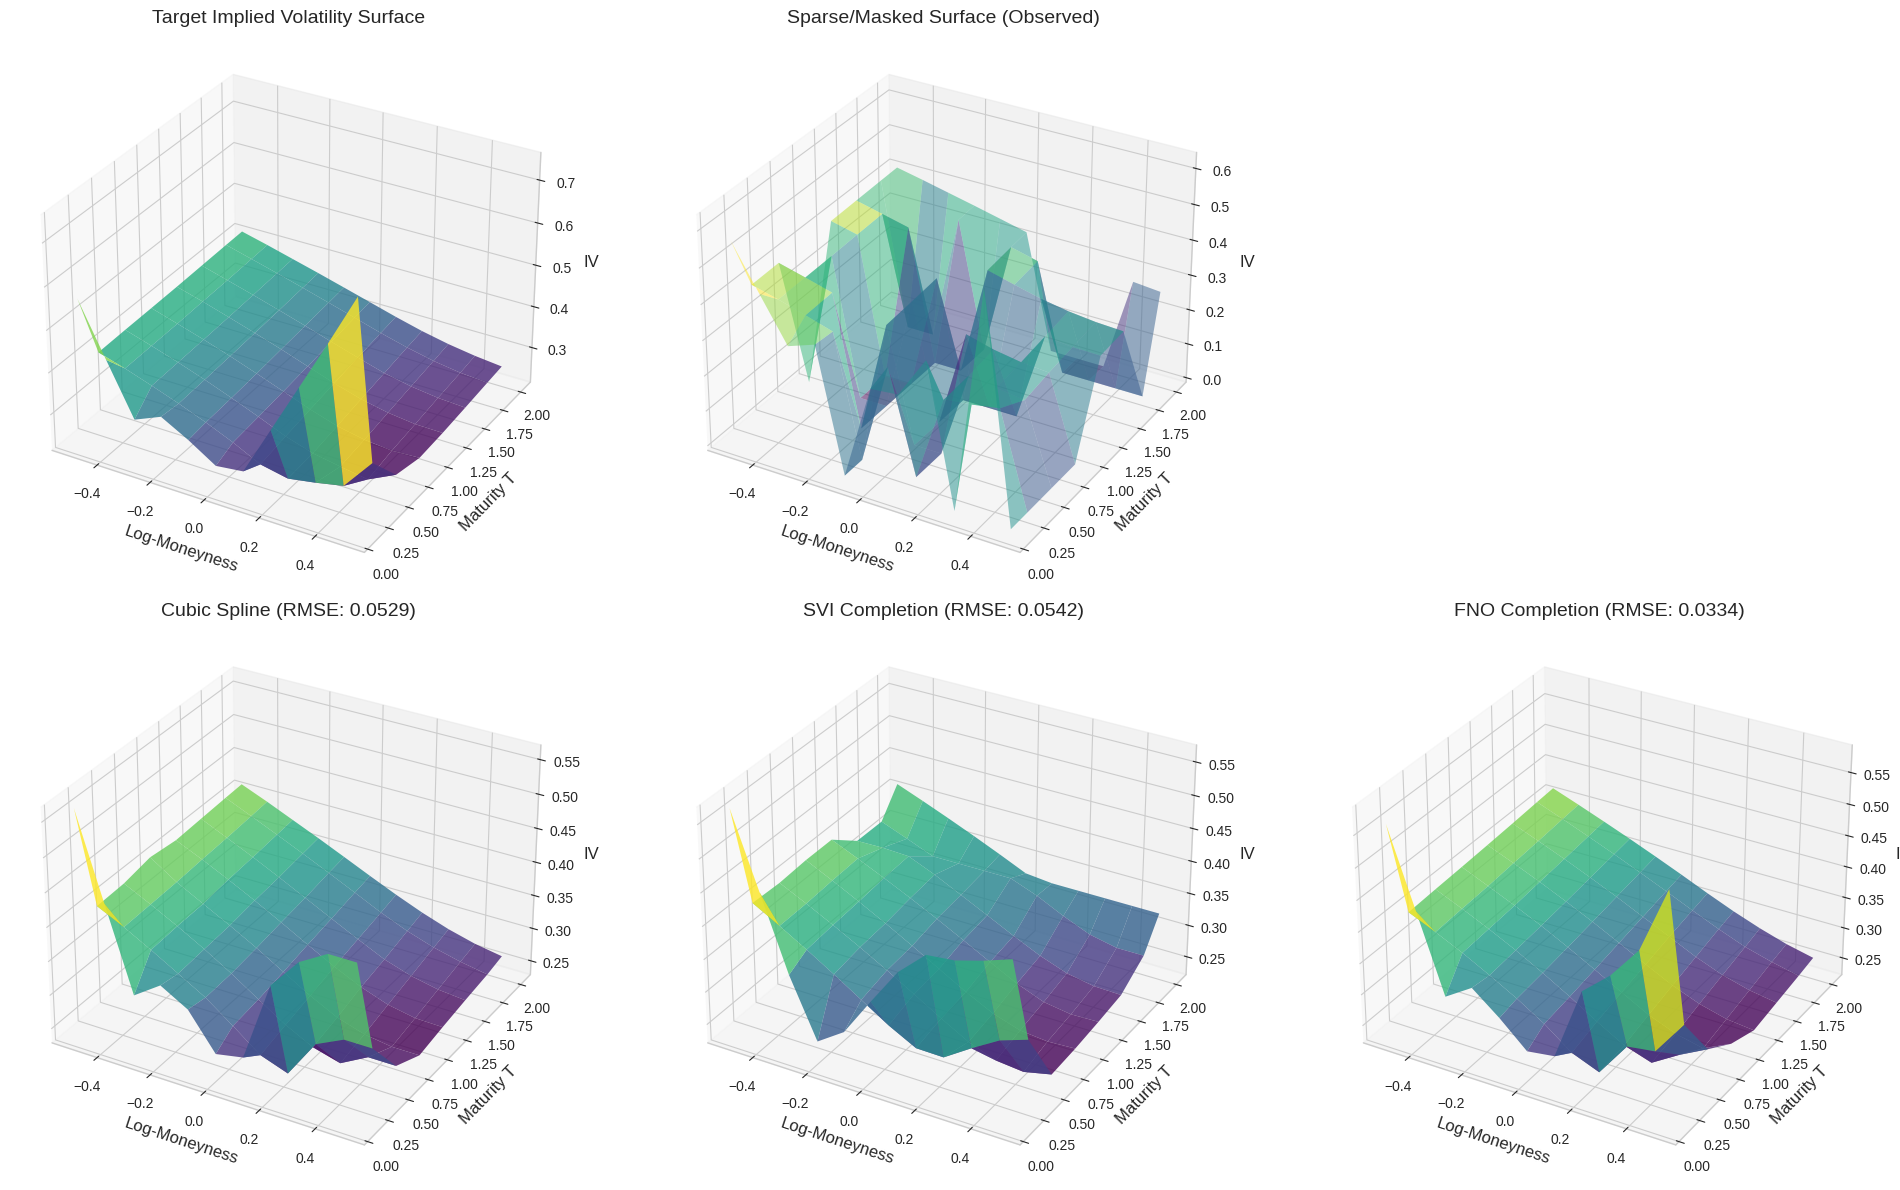

In [5]:
# Plot target vs completed surfaces
fig = plt.figure(figsize=(20, 12))

# Plot target surface (3D)
ax = fig.add_subplot(2, 3, 1, projection='3d')
T_mesh, K_mesh = np.meshgrid(T_GRID, K_GRID, indexing='ij')
surf = ax.plot_surface(K_mesh, T_mesh, target_surface, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title("Target Implied Volatility Surface", fontsize=14)
ax.set_xlabel("Log-Moneyness", fontsize=12)
ax.set_ylabel("Maturity T", fontsize=12)
ax.set_zlabel("IV", fontsize=12)

# Plot sparse (masked) surface (3D)
ax = fig.add_subplot(2, 3, 2, projection='3d')
sparse_for_plot = target_surface.copy()
sparse_for_plot[~mask] = 0.0 # set masked to zero for 3D visibility
ax.plot_surface(K_mesh, T_mesh, sparse_for_plot, cmap='viridis', edgecolor='none', alpha=0.5)
ax.set_title("Sparse/Masked Surface (Observed)", fontsize=14)
ax.set_xlabel("Log-Moneyness", fontsize=12)
ax.set_ylabel("Maturity T", fontsize=12)
ax.set_zlabel("IV", fontsize=12)

# Plot Cubic Spline completed surface
ax = fig.add_subplot(2, 3, 4, projection='3d')
ax.plot_surface(K_mesh, T_mesh, completed_surfaces["cubic_spline"], cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title(f"Cubic Spline (RMSE: {results['cubic_spline']['rmse']:.4f})", fontsize=14)
ax.set_xlabel("Log-Moneyness", fontsize=12)
ax.set_ylabel("Maturity T", fontsize=12)
ax.set_zlabel("IV", fontsize=12)

# Plot SVI completed surface
ax = fig.add_subplot(2, 3, 5, projection='3d')
ax.plot_surface(K_mesh, T_mesh, completed_surfaces["svi"], cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title(f"SVI Completion (RMSE: {results['svi']['rmse']:.4f})", fontsize=14)
ax.set_xlabel("Log-Moneyness", fontsize=12)
ax.set_ylabel("Maturity T", fontsize=12)
ax.set_zlabel("IV", fontsize=12)

# Plot FNO completed surface
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot_surface(K_mesh, T_mesh, completed_surfaces["fno"], cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title(f"FNO Completion (RMSE: {results['fno']['rmse']:.4f})", fontsize=14)
ax.set_xlabel("Log-Moneyness", fontsize=12)
ax.set_ylabel("Maturity T", fontsize=12)
ax.set_zlabel("IV", fontsize=12)

plt.tight_layout()
plt.show()


<string>:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


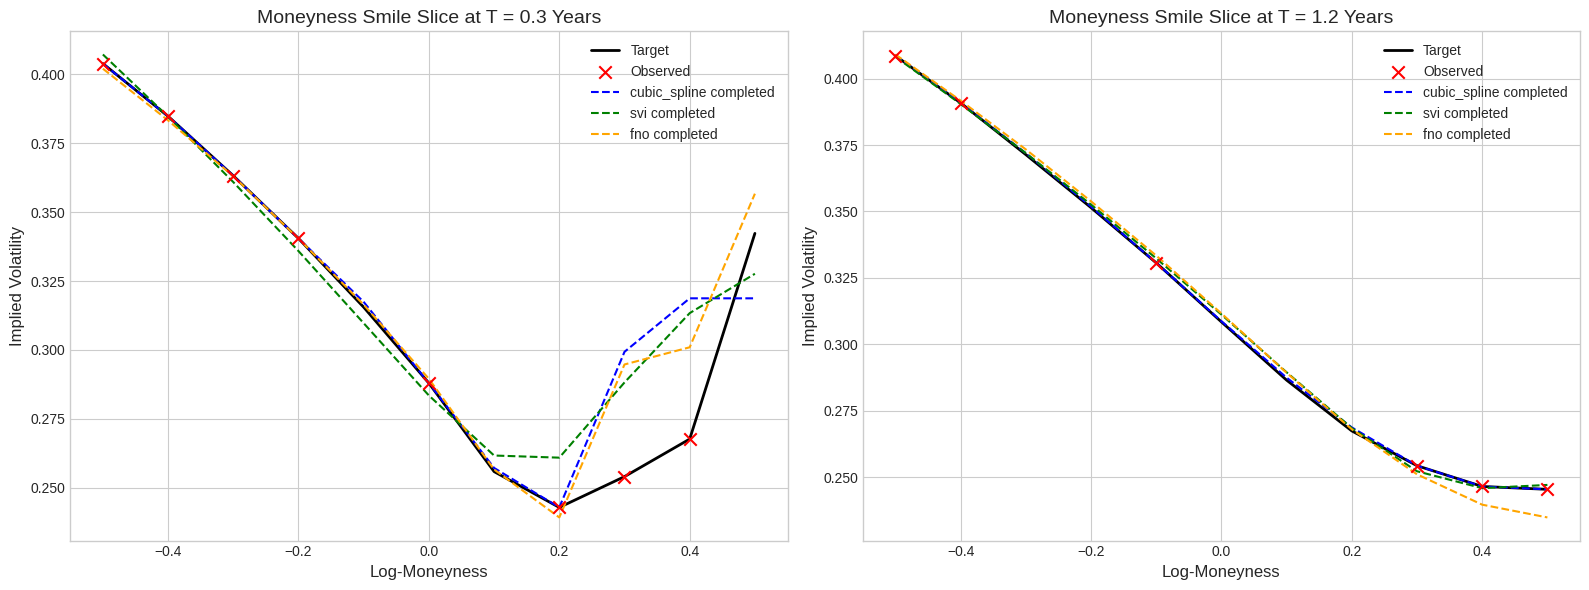

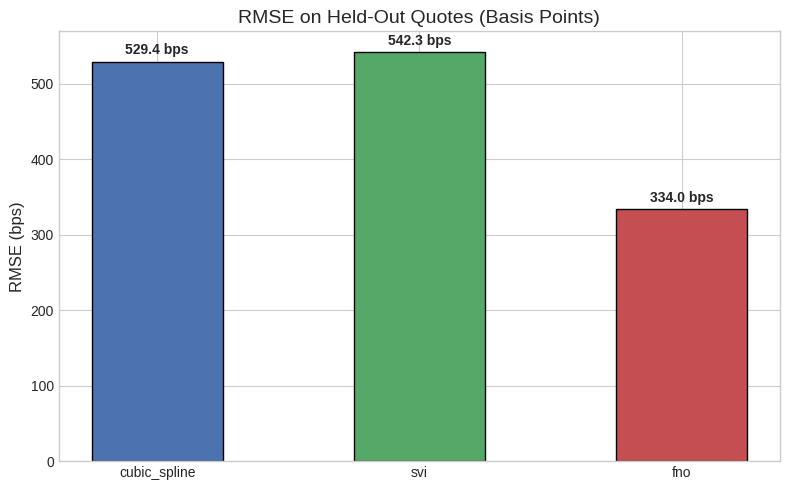

In [6]:
# Plot slices at T = 0.3 and T = 1.2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t_indices = [1, 4]  # T = 0.3 and T = 1.2
for idx, t_idx in enumerate(t_indices):
    ax = axes[idx]
    t_val = T_GRID[t_idx]
    
    # Target slice
    ax.plot(K_GRID, target_surface[t_idx], label="Target", color="black", linestyle="-", linewidth=2)
    
    # Observed points
    obs_k = K_GRID[mask[t_idx]]
    obs_iv = target_surface[t_idx][mask[t_idx]]
    ax.scatter(obs_k, obs_iv, label="Observed", color="red", marker="x", s=80, zorder=5)
    
    # Completed slices
    for method, color in zip(["cubic_spline", "svi", "fno"], ["blue", "green", "orange"]):
        ax.plot(K_GRID, completed_surfaces[method][t_idx], label=f"{method} completed", color=color, linestyle="--")
        
    ax.set_title(f"Moneyness Smile Slice at T = {t_val} Years", fontsize=14)
    ax.set_xlabel("Log-Moneyness", fontsize=12)
    ax.set_ylabel("Implied Volatility", fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Plot RMSE bar chart
fig, ax = plt.subplots(figsize=(8, 5))
methods = ["cubic_spline", "svi", "fno"]
rmses = [results[m]["rmse"] * 10000 for m in methods]  # convert to bps
colors = ["#4C72B0", "#55A868", "#C44E52"]

bars = ax.bar(methods, rmses, color=colors, edgecolor="black", width=0.5)
ax.set_title("RMSE on Held-Out Quotes (Basis Points)", fontsize=14)
ax.set_ylabel("RMSE (bps)", fontsize=12)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} bps',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
